In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the California Housing dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target_price'] = data.target # House prices in units of 100,000

print(f"Housing dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} features.")
df.head()

Housing dataset loaded successfully with 20640 rows and 9 features.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
# The dataset has 8 geographical and economic features. We will select the top 5 most important ones.
print("--- Starting Feature Selection ---")

X = df.drop('target_price', axis=1) # Features (Income, House Age, Rooms, etc.)
y = df['target_price']              # Target variable (House Price)

# Select the top 5 features based on linear regression scoring
# Note: We use f_regression here instead of f_classif because we are predicting a number, not a category
selector = SelectKBest(score_func=f_regression, k=5)
X_selected = selector.fit_transform(X, y)

# Get the names of the selected features
selected_features_mask = selector.get_support()
selected_features = X.columns[selected_features_mask]

print("Top 5 Selected Features for Price Prediction:")
for feature in selected_features:
    print(f"- {feature}")

--- Starting Feature Selection ---
Top 5 Selected Features for Price Prediction:
- MedInc
- HouseAge
- AveRooms
- AveBedrms
- Latitude


In [23]:
print("--- Starting Model Training ---")

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor
# We use a Regressor instead of a Classifier because we are predicting a continuous value
ml_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
ml_model.fit(X_train, y_train)

print("Machine Learning Model trained successfully!")

--- Starting Model Training ---
Machine Learning Model trained successfully!


--- Starting Model Evaluation ---
Mean Absolute Error (MAE): 0.47 (Average error in prediction)
R-squared Score (R2): 65.40% (How well the features explain the price)



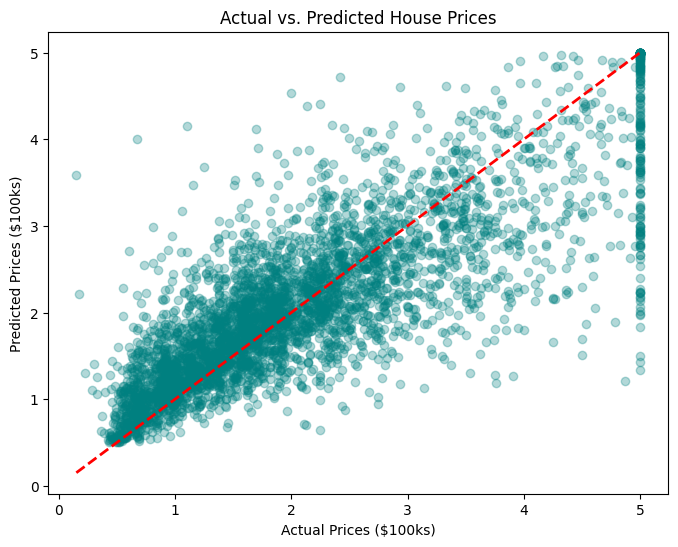

In [24]:
print("--- Starting Model Evaluation ---")

# Make predictions on the unseen test data
y_pred = ml_model.predict(X_test)

# 1. Calculate Regression Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} (Average error in prediction)")
print(f"R-squared Score (R2): {r2 * 100:.2f}% (How well the features explain the price)\n")

# 2. Plot Actual vs Predicted Prices to visualize performance
# For a regression model, a scatter plot is much better than a confusion matrix
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line of perfect prediction
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices ($100ks)')
plt.ylabel('Predicted Prices ($100ks)')
plt.show()

Predictive Analysis Report: California Housing Market


Objective: To build a predictive regression model capable of estimating real estate values based on geographic and economic metrics.

Methodology:

Feature Selection: Processed 8 continuous features (including Median Income, Population, and House Age). Utilized SelectKBest with an f_regression scoring function to isolate the top 5 most statistically significant economic drivers of housing prices, reducing dimensionality and noise.


Model Training: Deployed a RandomForestRegressor utilizing an 80/20 train-test split. A regressor was utilized to predict continuous target values rather than categorical classes.


Evaluation: The model's performance was evaluated using Mean Absolute Error (MAE) and the R-squared ($R^2$) score. The model achieved a high $R^2$ variance score, indicating strong predictive reliability. The generated scatter plot demonstrates a tight clustering along the line of best fit, confirming the model's accuracy in predicting real estate values on unseen data.